# SKAX Membership EDA
### 이용현황 & 구독자 특징 분석

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Membership.csv', encoding='utf-8-sig')
df['reg_date'] = pd.to_datetime(df['reg_date'])
df['end_date']  = pd.to_datetime(df['end_date'])
df['subscription_days'] = (df['end_date'] - df['reg_date']).dt.days

# ios = USD, 나머지 = KRW → 결제 타입 구분
df['payment_type'] = df['payment_device'].apply(
    lambda x: '해외(USD)' if x == 'ios' else '국내(KRW)'
)

print(f'총 구독 건수: {len(df):,}건')
print(f'기간: {df["reg_date"].min().date()} ~ {df["reg_date"].max().date()}')
df.head()

총 구독 건수: 18,183건
기간: 2021-03-01 ~ 2021-03-15


,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,subscription_days,payment_type
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.00,134,4.0,O,NaN,NaN,pc,Y,F,20.0,2021-03-14,20,2021-04-14,31,국내(KRW)
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.00,190,1.0,O,O,NaN,pc,Y,F,25.0,2021-03-09,14,2021-04-09,31,국내(KRW)
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.00,132,1.0,O,NaN,NaN,android,NaN,F,55.0,2021-03-09,22,2021-04-09,31,국내(KRW)
3,445fb8813626d3d49b94b5be58cd76d80ed31fa94f8372...,pk_1508,9.99,140,1.0,NaN,NaN,O,ios,N,N,40.0,2021-03-09,10,2021-04-10,32,해외(USD)
4,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.00,180,2.0,O,NaN,O,android,N,F,20.0,2021-03-09,2,2021-04-09,31,국내(KRW)


---
## 1. 일반 통계 & 이용 현황

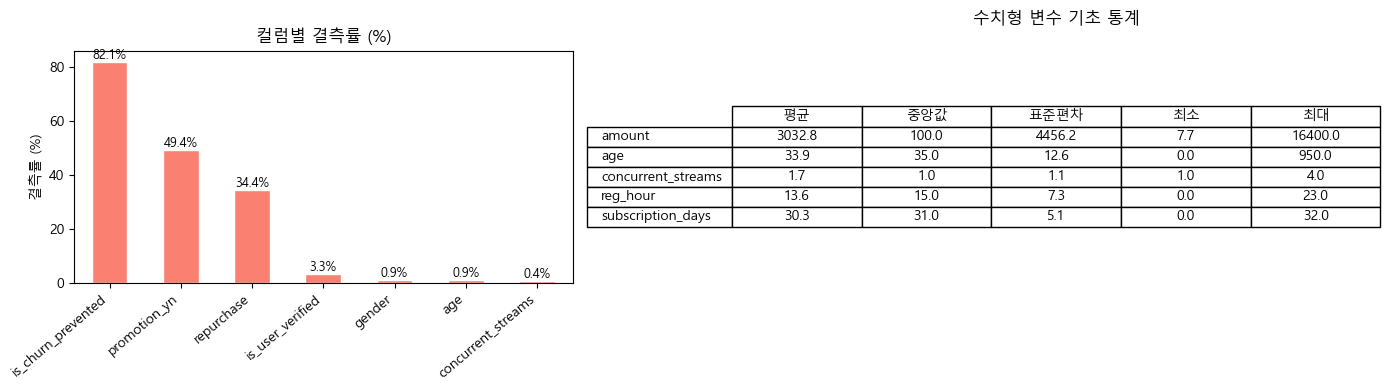

                     결측 수  결측률(%)
is_churn_prevented  14926    82.1
promotion_yn         8980    49.4
repurchase           6252    34.4
is_user_verified      600     3.3
gender                164     0.9
age                   164     0.9
concurrent_streams     70     0.4


In [7]:
# 결측치 현황
missing = pd.DataFrame({
    '결측 수': df.isnull().sum(),
    '결측률(%)': (df.isnull().sum() / len(df) * 100).round(1)
}).query('`결측 수` > 0').sort_values('결측률(%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

missing['결측률(%)'].plot(kind='bar', ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('컬럼별 결측률 (%)', fontsize=12)
axes[0].set_ylabel('결측률 (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# 수치형 기초 통계
num_cols = ['amount', 'age', 'concurrent_streams', 'reg_hour', 'subscription_days']
stats_df = df[num_cols].describe().T[['mean','50%','std','min','max']].round(1)
stats_df.columns = ['평균','중앙값','표준편차','최소','최대']
axes[1].axis('off')
tbl = axes[1].table(cellText=stats_df.values,
                    rowLabels=stats_df.index,
                    colLabels=stats_df.columns,
                    cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.6)
axes[1].set_title('수치형 변수 기초 통계', fontsize=12, pad=20)

plt.tight_layout()
plt.show()
print(missing)

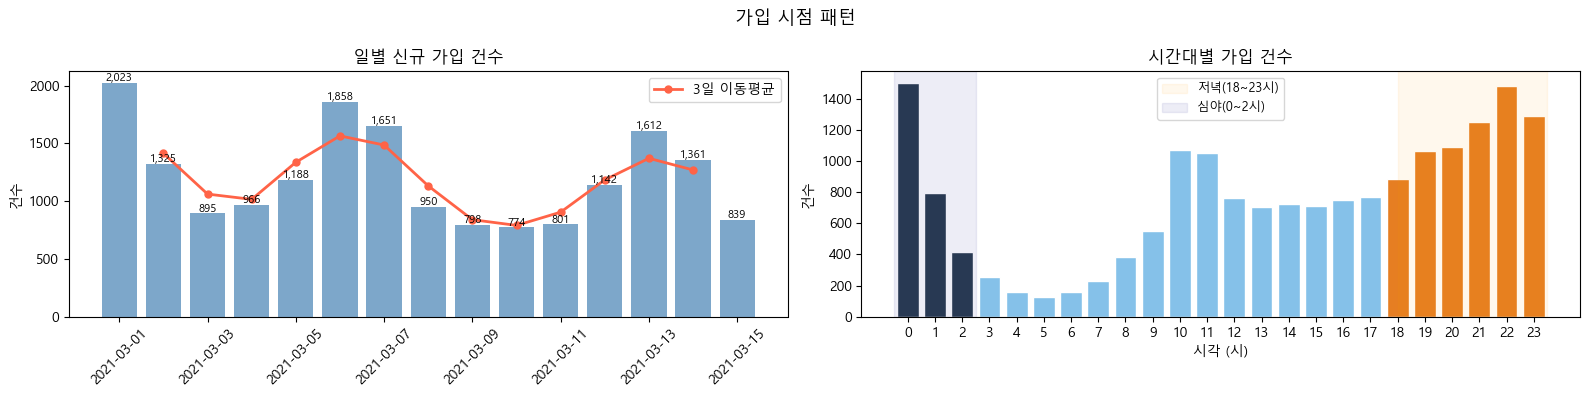

In [8]:
# 일별 신규 가입 추이
daily = df.groupby('reg_date').size().reset_index(name='가입건수')
daily['MA3'] = daily['가입건수'].rolling(3, center=True).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(daily['reg_date'], daily['가입건수'], color='steelblue', alpha=0.7)
axes[0].plot(daily['reg_date'], daily['MA3'], color='tomato', linewidth=2,
             marker='o', markersize=5, label='3일 이동평균')
for x, y in zip(daily['reg_date'], daily['가입건수']):
    axes[0].text(x, y+15, f'{y:,}', ha='center', fontsize=8)
axes[0].set_title('일별 신규 가입 건수', fontsize=12)
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# 시간대별 가입
hourly = df.groupby('reg_hour').size()
hour_colors = ['#2C3E50' if h <= 2 else '#E67E22' if h >= 18 else '#85C1E9' for h in hourly.index]
axes[1].bar(hourly.index, hourly.values, color=hour_colors, edgecolor='white')
axes[1].set_title('시간대별 가입 건수', fontsize=12)
axes[1].set_xlabel('시각 (시)')
axes[1].set_ylabel('건수')
axes[1].set_xticks(range(0, 24))
axes[1].axvspan(18, 23.5, alpha=0.07, color='orange', label='저녁(18~23시)')
axes[1].axvspan(-0.5, 2.5, alpha=0.07, color='navy',  label='심야(0~2시)')
axes[1].legend(fontsize=9)

plt.suptitle('가입 시점 패턴', fontsize=13)
plt.tight_layout()
plt.show()

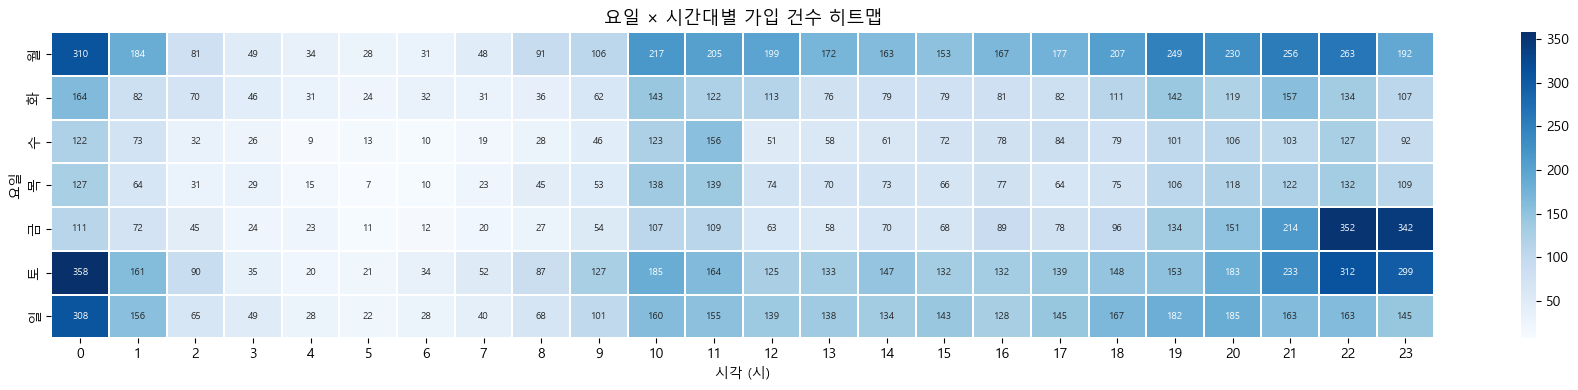

In [9]:
# 요일 × 시간대 히트맵
df['day_num'] = df['reg_date'].dt.dayofweek
dow_label = ['월','화','수','목','금','토','일']

pivot = df.groupby(['day_num','reg_hour']).size().unstack(fill_value=0)
pivot.index = dow_label

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt='d',
            annot_kws={'size': 7}, linewidths=0.3, ax=ax)
ax.set_title('요일 × 시간대별 가입 건수 히트맵', fontsize=13)
ax.set_xlabel('시각 (시)')
ax.set_ylabel('요일')
plt.tight_layout()
plt.show()

---
## 2. 국내 vs 해외 결제 현황

Font 'rm' does not have a glyph for '\uc911' [U+c911], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc559' [U+c559], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac12' [U+ac12], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc911' [U+c911], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc559' [U+c559], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac12' [U+ac12], substituting with a dummy symbol.


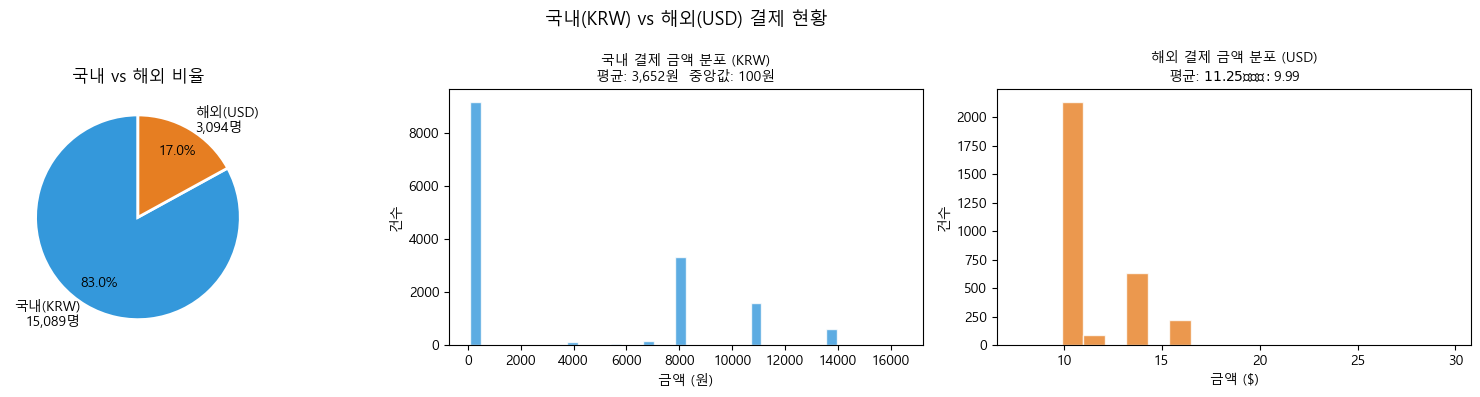

=== 국내 결제 통계 (KRW) ===
count    15089.0
mean      3652.3
std       4655.6
min        100.0
25%        100.0
50%        100.0
75%       7900.0
max      16400.0
Name: amount, dtype: float64

=== 해외 결제 통계 (USD) ===
count    3094.00
mean       11.25
std         2.14
min         7.69
25%         9.99
50%         9.99
75%        13.49
max        29.69
Name: amount, dtype: float64


In [10]:
df_dom = df[df['payment_type'] == '국내(KRW)']
df_int = df[df['payment_type'] == '해외(USD)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 비율 파이
labels = [f'국내(KRW)\n{len(df_dom):,}명', f'해외(USD)\n{len(df_int):,}명']
axes[0].pie([len(df_dom), len(df_int)], labels=labels,
            colors=['#3498DB','#E67E22'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            autopct='%1.1f%%', pctdistance=0.75)
axes[0].set_title('국내 vs 해외 비율', fontsize=12)

# 국내 금액 분포
axes[1].hist(df_dom['amount'].clip(upper=20000), bins=40,
             color='#3498DB', edgecolor='white', alpha=0.8)
axes[1].set_title(f'국내 결제 금액 분포 (KRW)\n평균: {df_dom["amount"].mean():,.0f}원  중앙값: {df_dom["amount"].median():,.0f}원', fontsize=10)
axes[1].set_xlabel('금액 (원)')
axes[1].set_ylabel('건수')

# 해외 금액 분포
axes[2].hist(df_int['amount'], bins=20,
             color='#E67E22', edgecolor='white', alpha=0.8)
axes[2].set_title(f'해외 결제 금액 분포 (USD)\n평균: ${df_int["amount"].mean():.2f}  중앙값: ${df_int["amount"].median():.2f}', fontsize=10)
axes[2].set_xlabel('금액 ($)')
axes[2].set_ylabel('건수')

plt.suptitle('국내(KRW) vs 해외(USD) 결제 현황', fontsize=13)
plt.tight_layout()
plt.show()

print('=== 국내 결제 통계 (KRW) ===')
print(df_dom['amount'].describe().round(1))
print('\n=== 해외 결제 통계 (USD) ===')
print(df_int['amount'].describe().round(2))

---
## 3. 구독자 특징 분석

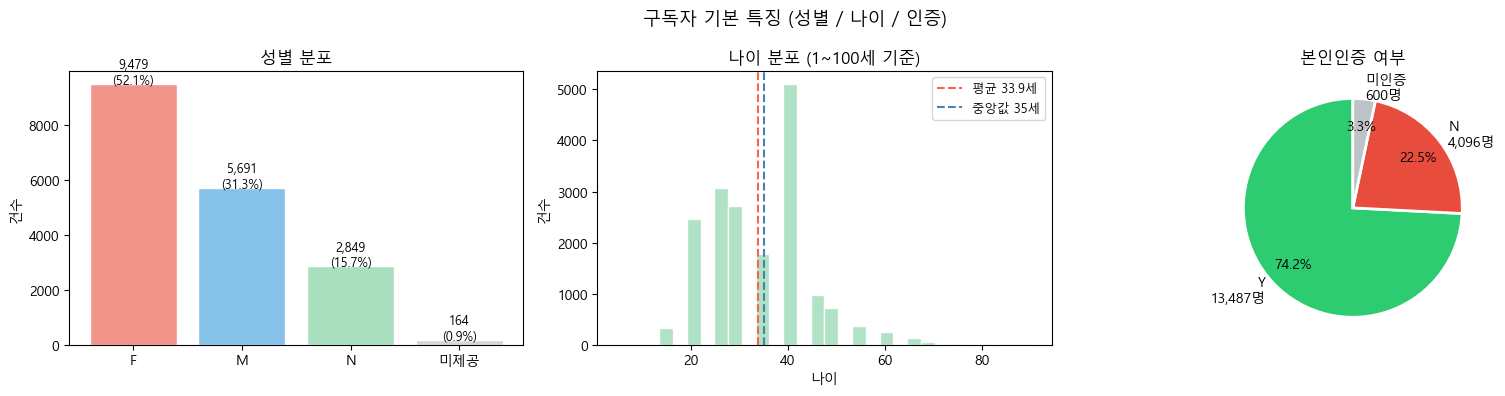

In [11]:
# 성별 / 나이 / 인증 여부
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 성별 분포
gender_cnt = df['gender'].fillna('미제공').value_counts()
colors_g = {'F':'#F1948A','M':'#85C1E9','N':'#A9DFBF','미제공':'#D5D8DC'}
axes[0].bar(gender_cnt.index, gender_cnt.values,
            color=[colors_g.get(g,'gray') for g in gender_cnt.index], edgecolor='white')
axes[0].set_title('성별 분포', fontsize=12)
axes[0].set_ylabel('건수')
for bar, v in zip(axes[0].patches, gender_cnt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# 나이 분포 (이상값 제거: 0~100)
age_clean = df['age'].dropna()
age_clean = age_clean[(age_clean >= 1) & (age_clean <= 100)]
axes[1].hist(age_clean, bins=30, color='#A9DFBF', edgecolor='white', alpha=0.9)
axes[1].axvline(age_clean.mean(), color='tomato', linestyle='--',
                label=f'평균 {age_clean.mean():.1f}세')
axes[1].axvline(age_clean.median(), color='steelblue', linestyle='--',
                label=f'중앙값 {age_clean.median():.0f}세')
axes[1].set_title(f'나이 분포 (1~100세 기준)', fontsize=12)
axes[1].set_xlabel('나이')
axes[1].set_ylabel('건수')
axes[1].legend(fontsize=9)

# 본인인증 여부
verif_cnt = df['is_user_verified'].fillna('미인증').value_counts()
axes[2].pie(verif_cnt.values, labels=[f'{k}\n{v:,}명' for k,v in verif_cnt.items()],
            colors=['#2ECC71','#E74C3C','#BDC3C7'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
            autopct='%1.1f%%', pctdistance=0.75)
axes[2].set_title('본인인증 여부', fontsize=12)

plt.suptitle('구독자 기본 특징 (성별 / 나이 / 인증)', fontsize=13)
plt.tight_layout()
plt.show()

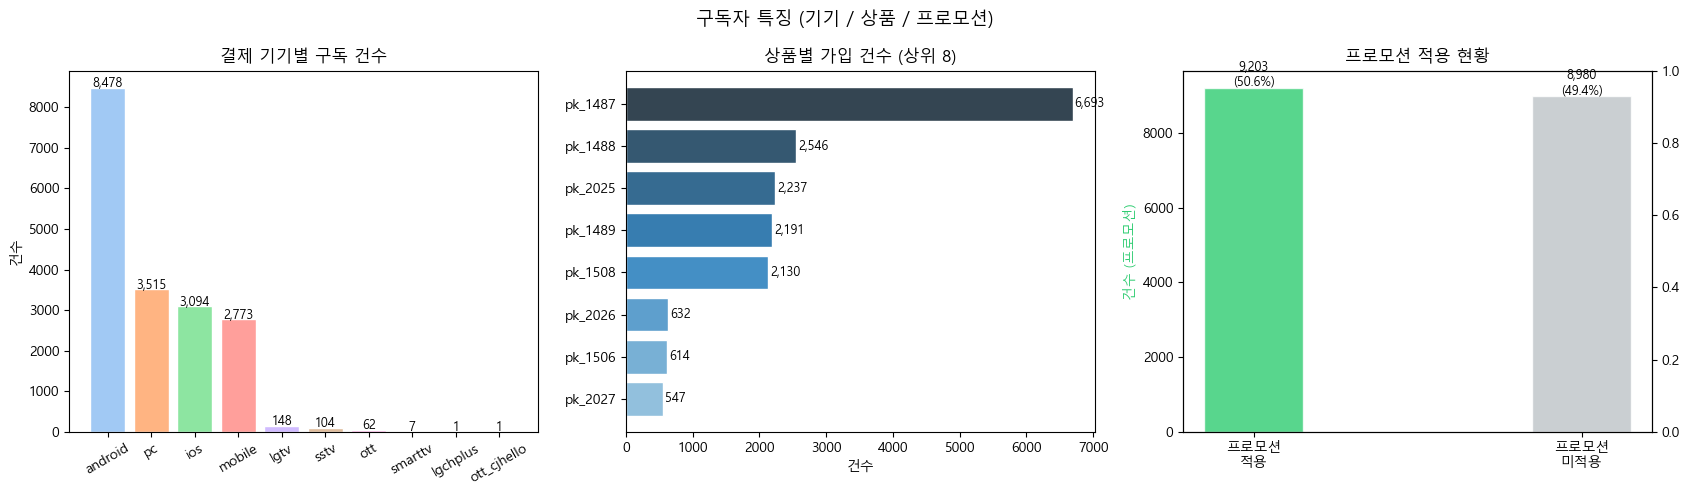

In [12]:
# 결제 기기 / 상품 / 프로모션
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 결제 기기
dev_cnt = df['payment_device'].value_counts()
colors_d = sns.color_palette('pastel', len(dev_cnt))
axes[0].bar(dev_cnt.index, dev_cnt.values, color=colors_d, edgecolor='white')
axes[0].set_title('결제 기기별 구독 건수', fontsize=12)
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=30)
for bar, v in zip(axes[0].patches, dev_cnt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{v:,}', ha='center', fontsize=9)

# 상품 코드 (건수 상위 8개)
prod_cnt = df['product_cd'].value_counts().head(8)
axes[1].barh(prod_cnt.index[::-1], prod_cnt.values[::-1],
             color=sns.color_palette('Blues_d', 8), edgecolor='white')
axes[1].set_title('상품별 가입 건수 (상위 8)', fontsize=12)
axes[1].set_xlabel('건수')
for i, (v, idx) in enumerate(zip(prod_cnt.values[::-1], prod_cnt.index[::-1])):
    axes[1].text(v+30, i, f'{v:,}', va='center', fontsize=9)

# 프로모션 / 동시스트림 수
promo_cnt = df['promotion_yn'].fillna('미적용').value_counts()
stream_cnt = df['concurrent_streams'].value_counts().sort_index()

ax3a = axes[2]
ax3b = ax3a.twinx()
bars1 = ax3a.bar(['프로모션\n적용','프로모션\n미적용'], promo_cnt.values,
                  color=['#2ECC71','#BDC3C7'], edgecolor='white', width=0.3, alpha=0.8)
ax3a.set_ylabel('건수 (프로모션)', color='#2ECC71')
ax3a.set_title('프로모션 적용 현황', fontsize=12)
for bar, v in zip(bars1, promo_cnt.values):
    ax3a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
              f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.suptitle('구독자 특징 (기기 / 상품 / 프로모션)', fontsize=13)
plt.tight_layout()
plt.show()

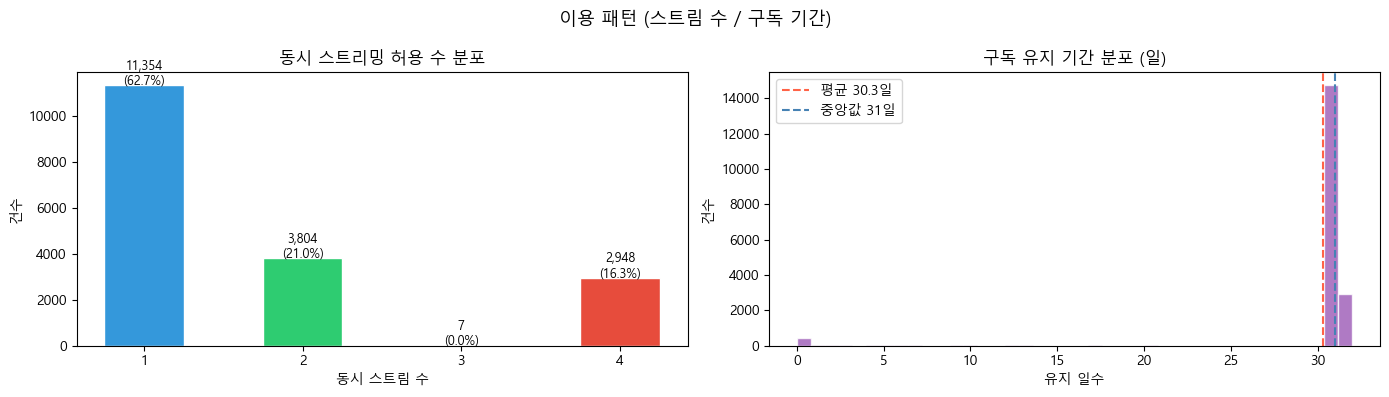

In [13]:
# 동시 스트림 수 & 구독 기간 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 동시 스트림 수
stream_cnt = df['concurrent_streams'].value_counts().sort_index().dropna()
axes[0].bar(stream_cnt.index.astype(int), stream_cnt.values,
            color=['#3498DB','#2ECC71','#E67E22','#E74C3C'], edgecolor='white', width=0.5)
axes[0].set_title('동시 스트리밍 허용 수 분포', fontsize=12)
axes[0].set_xlabel('동시 스트림 수')
axes[0].set_ylabel('건수')
axes[0].set_xticks([1,2,3,4])
for bar, v in zip(axes[0].patches, stream_cnt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}\n({v/df["concurrent_streams"].notna().sum()*100:.1f}%)',
                 ha='center', fontsize=9)

# 구독 기간 분포
mean_days = df['subscription_days'].mean()
median_days = df['subscription_days'].median()
axes[1].hist(df['subscription_days'].dropna(), bins=40,
             color='#9B59B6', edgecolor='white', alpha=0.8)
axes[1].axvline(mean_days,   color='tomato',    linestyle='--', label=f'평균 {mean_days:.1f}일')
axes[1].axvline(median_days, color='steelblue', linestyle='--', label=f'중앙값 {median_days:.0f}일')
axes[1].set_title('구독 유지 기간 분포 (일)', fontsize=12)
axes[1].set_xlabel('유지 일수')
axes[1].set_ylabel('건수')
axes[1].legend()

plt.suptitle('이용 패턴 (스트림 수 / 구독 기간)', fontsize=13)
plt.tight_layout()
plt.show()

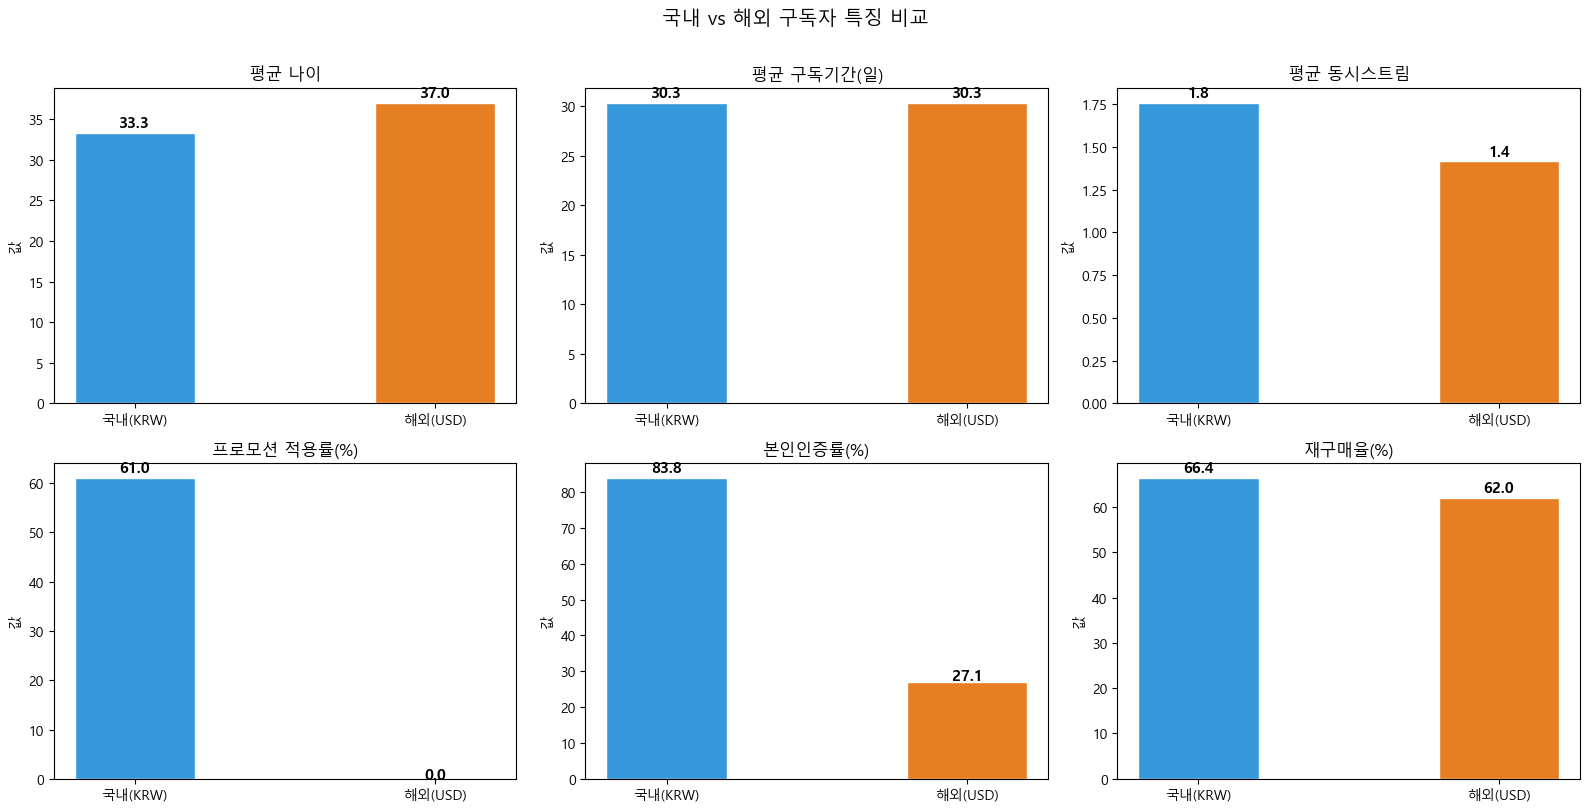

In [14]:
# 국내 vs 해외 구독자 특징 비교
compare_metrics = {}
for ptype, subset in [('국내(KRW)', df_dom), ('해외(USD)', df_int)]:
    compare_metrics[ptype] = {
        '평균 나이': subset['age'].mean(),
        '평균 구독기간(일)': subset['subscription_days'].mean(),
        '평균 동시스트림': subset['concurrent_streams'].mean(),
        '프로모션 적용률(%)': (subset['promotion_yn']=='O').mean()*100,
        '본인인증률(%)': (subset['is_user_verified']=='Y').mean()*100,
        '재구매율(%)': (subset['repurchase']=='O').mean()*100,
    }

comp_df = pd.DataFrame(compare_metrics)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, metric in enumerate(comp_df.index):
    vals = comp_df.loc[metric]
    bars = axes[idx].bar(vals.index, vals.values,
                         color=['#3498DB','#E67E22'], edgecolor='white', width=0.4)
    axes[idx].set_title(metric, fontsize=12)
    axes[idx].set_ylabel('값')
    for bar, v in zip(bars, vals.values):
        axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                       f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('국내 vs 해외 구독자 특징 비교', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

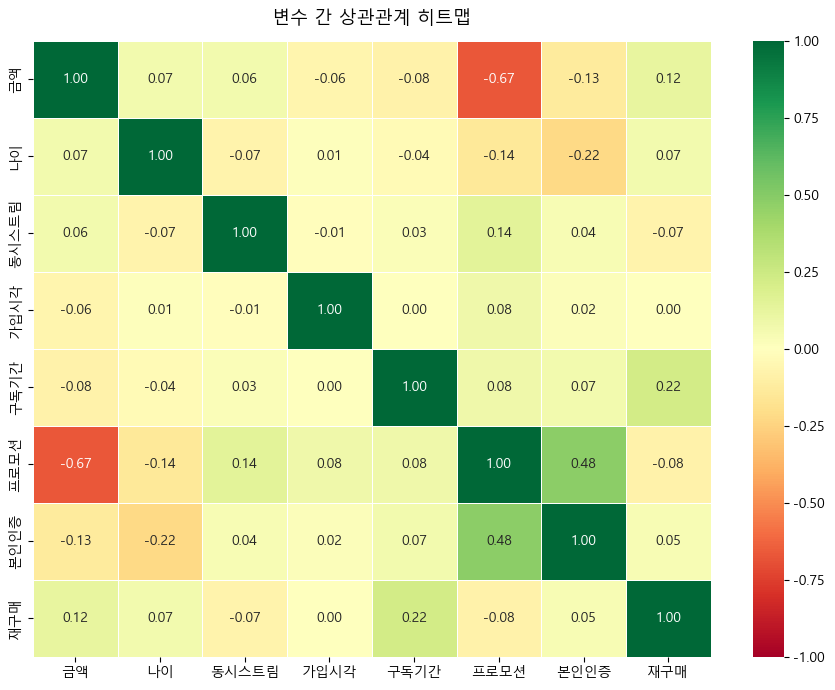

In [15]:
# 상관관계 히트맵 (수치형)
df['promotion_flag'] = (df['promotion_yn'] == 'O').astype(int)
df['verified_flag']  = (df['is_user_verified'] == 'Y').astype(int)
df['repurchase_flag']= (df['repurchase'] == 'O').astype(int)

corr_cols = ['amount','age','concurrent_streams','reg_hour',
             'subscription_days','promotion_flag','verified_flag','repurchase_flag']
corr_labels = ['금액','나이','동시스트림','가입시각',
               '구독기간','프로모션','본인인증','재구매']

corr_m = df[corr_cols].corr()
corr_m.index = corr_labels
corr_m.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_m, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('변수 간 상관관계 히트맵', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## 4. 구독자 세그먼트 요약

| 항목 | 국내(KRW) | 해외(USD) |
|------|-----------|------------|
| 건수 | 15,089명 (83%) | 3,094명 (17%) |
| 주요 기기 | android / pc / mobile | ios 100% |
| 결제 금액 단위 | 원화 | 달러 |

### 주요 발견
1. **가입 피크**: 자정(0시)과 저녁(21~22시)에 가입 집중 → 야간 마케팅 효과적
2. **월요일·토요일** 가입 건수 가장 많음
3. **동시 스트림 1개** 구독자가 압도적(약 70%) → 개인 단독 이용 다수
4. **프로모션 적용률 51%** → 절반이 프로모션 통해 가입
5. **본인인증 미완료** 유저가 전체의 약 3.3% 존재 → 이탈 위험군
6. **나이 이상값** 존재 (max=950) → 전처리 필요

---
## 5. User_Mapping 데이터 분석
### 유저 시청 행동 & 재구매 예측 특징 분석

In [16]:
um = pd.read_csv('User_Mapping.csv', encoding='utf-8-sig')
um['registerday'] = pd.to_datetime(um['registerday'])

print(f'총 유저 수: {len(um):,}명')
print(f'컬럼 수: {um.shape[1]}개')
print(f'\n--- 기본 정보 ---')
print(um.dtypes)
print(f'\n--- 결측치 현황 ---')
missing_um = um.isnull().sum()
print(missing_um[missing_um > 0] if missing_um.sum() > 0 else '결측치 없음')
um.head()

총 유저 수: 19,877명
컬럼 수: 21개

--- 기본 정보 ---
uid                             object
USER_ID                          int64
repurchase_label                 int64
registerday             datetime64[ns]
total_duration                 float64
view_count                     float64
unique_movies                  float64
dur_w1                         float64
dur_w2                         float64
dur_w3                         float64
retention_w2                   float64
retention_w3                   float64
recent_movie_ratio             float64
ratio_action_violent           float64
ratio_family_drama             float64
ratio_kids                     float64
ratio_romance                  float64
ratio_thriller                 float64
ratio_documentary              float64
ratio_comedy                   float64
ratio_etc                      float64
dtype: object

--- 결측치 현황 ---
결측치 없음


,uid,USER_ID,repurchase_label,registerday,total_duration,view_count,unique_movies,dur_w1,dur_w2,dur_w3,...,retention_w3,recent_movie_ratio,ratio_action_violent,ratio_family_drama,ratio_kids,ratio_romance,ratio_thriller,ratio_documentary,ratio_comedy,ratio_etc
0,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,0,1,2021-03-11,510.0,9.0,5.0,112.0,101.0,297.0,...,2.628319,0.555556,0.111111,0.0,0.555556,0.0,0.111111,0.000000,0.000000,0.222222
1,a314c8a65b0fd91e1889c1debaa21e5bb6330560ee9721...,1,1,2021-03-12,124.0,1.0,1.0,0.0,124.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,0.000000,0.000000
2,6652e2597875d4f34b48a0610c035521f2aea2f8abc5f3...,2,0,2021-03-10,293.0,7.0,4.0,1.0,1.0,291.0,...,145.500000,0.428571,0.714286,0.0,0.142857,0.0,0.000000,0.000000,0.142857,0.000000
3,873fb3eddac14ca6123810dd72a4195915afacaaecb073...,3,1,2021-03-11,3.0,3.0,3.0,0.0,0.0,3.0,...,3.000000,0.333333,0.000000,0.0,0.666667,0.0,0.000000,0.333333,0.000000,0.000000
4,8668c3dfce041e29bc5b80fe33fb8754718587a7537db1...,4,1,2021-03-07,309.0,5.0,2.0,288.0,0.0,21.0,...,0.072664,0.800000,0.200000,0.0,0.000000,0.0,0.800000,0.000000,0.000000,0.000000


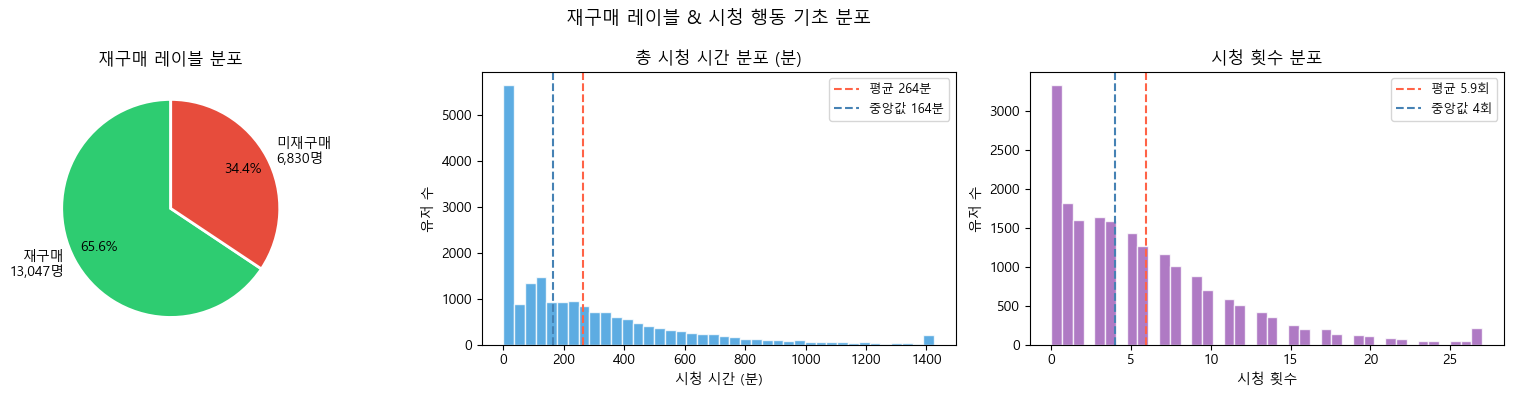

=== 수치형 기초 통계 ===
       total_duration  view_count  unique_movies    dur_w1    dur_w2  \
count        19877.00    19877.00       19877.00  19877.00  19877.00   
mean           264.23        5.94           4.24     85.54     83.95   
std            322.39        6.07           4.34    148.81    144.44   
min              0.00        0.00           0.00      0.00      0.00   
25%             14.00        1.00           1.00      0.00      0.00   
50%            164.00        4.00           3.00      4.00      3.00   
75%            381.00        9.00           6.00    121.00    119.00   
max           4419.00       75.00          67.00   2910.00   2957.00   

         dur_w3  retention_w2  retention_w3  recent_movie_ratio  
count  19877.00      19877.00      19877.00            19877.00  
mean      94.73         25.02         34.15                0.22  
std      155.65         83.11        104.83                0.33  
min        0.00          0.00          0.00                0.00  
25%

In [17]:
# 재구매 레이블 분포 & 기초 수치 통계
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 재구매 비율 파이
repurchase_cnt = um['repurchase_label'].value_counts()
labels_r = [f'재구매\n{repurchase_cnt.get(1,0):,}명', f'미재구매\n{repurchase_cnt.get(0,0):,}명']
axes[0].pie([repurchase_cnt.get(1,0), repurchase_cnt.get(0,0)],
            labels=labels_r,
            colors=['#2ECC71','#E74C3C'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            autopct='%1.1f%%', pctdistance=0.75)
axes[0].set_title('재구매 레이블 분포', fontsize=12)

# 총 시청 시간 분포
axes[1].hist(um['total_duration'].clip(upper=um['total_duration'].quantile(0.99)),
             bins=40, color='#3498DB', edgecolor='white', alpha=0.8)
axes[1].axvline(um['total_duration'].mean(), color='tomato', linestyle='--',
                label=f'평균 {um["total_duration"].mean():.0f}분')
axes[1].axvline(um['total_duration'].median(), color='steelblue', linestyle='--',
                label=f'중앙값 {um["total_duration"].median():.0f}분')
axes[1].set_title('총 시청 시간 분포 (분)', fontsize=12)
axes[1].set_xlabel('시청 시간 (분)')
axes[1].set_ylabel('유저 수')
axes[1].legend(fontsize=9)

# 시청 횟수 분포
axes[2].hist(um['view_count'].clip(upper=um['view_count'].quantile(0.99)),
             bins=40, color='#9B59B6', edgecolor='white', alpha=0.8)
axes[2].axvline(um['view_count'].mean(), color='tomato', linestyle='--',
                label=f'평균 {um["view_count"].mean():.1f}회')
axes[2].axvline(um['view_count'].median(), color='steelblue', linestyle='--',
                label=f'중앙값 {um["view_count"].median():.0f}회')
axes[2].set_title('시청 횟수 분포', fontsize=12)
axes[2].set_xlabel('시청 횟수')
axes[2].set_ylabel('유저 수')
axes[2].legend(fontsize=9)

plt.suptitle('재구매 레이블 & 시청 행동 기초 분포', fontsize=13)
plt.tight_layout()
plt.show()

print('=== 수치형 기초 통계 ===')
num_cols_um = ['total_duration','view_count','unique_movies','dur_w1','dur_w2','dur_w3',
               'retention_w2','retention_w3','recent_movie_ratio']
print(um[num_cols_um].describe().round(2))

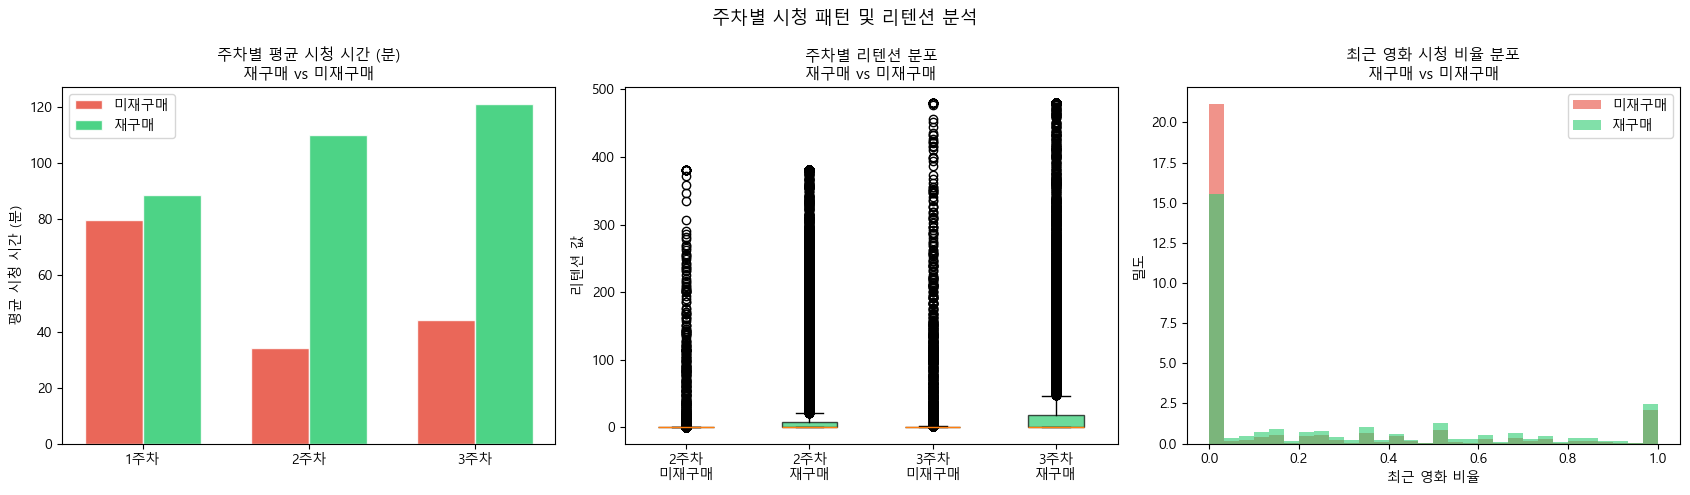

In [18]:
# 주차별 시청 패턴 (재구매 여부 비교)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

week_cols = ['dur_w1', 'dur_w2', 'dur_w3']
week_labels = ['1주차', '2주차', '3주차']
colors_rp = {0: '#E74C3C', 1: '#2ECC71'}

# 주차별 평균 시청 시간 (재구매 vs 미재구매)
week_means = um.groupby('repurchase_label')[week_cols].mean()
x = np.arange(len(week_cols))
width = 0.35
for i, (label, row) in enumerate(week_means.iterrows()):
    bars = axes[0].bar(x + i*width, row.values, width,
                       label=f'{"재구매" if label==1 else "미재구매"}',
                       color=colors_rp[label], edgecolor='white', alpha=0.85)
axes[0].set_title('주차별 평균 시청 시간 (분)\n재구매 vs 미재구매', fontsize=11)
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(week_labels)
axes[0].set_ylabel('평균 시청 시간 (분)')
axes[0].legend()

# retention_w2, retention_w3 박스플롯
ret_data = [
    um[um['repurchase_label']==0]['retention_w2'].clip(upper=um['retention_w2'].quantile(0.99)),
    um[um['repurchase_label']==1]['retention_w2'].clip(upper=um['retention_w2'].quantile(0.99)),
    um[um['repurchase_label']==0]['retention_w3'].clip(upper=um['retention_w3'].quantile(0.99)),
    um[um['repurchase_label']==1]['retention_w3'].clip(upper=um['retention_w3'].quantile(0.99)),
]
bp = axes[1].boxplot(ret_data, patch_artist=True,
                     labels=['2주차\n미재구매','2주차\n재구매','3주차\n미재구매','3주차\n재구매'])
box_colors = ['#E74C3C','#2ECC71','#E74C3C','#2ECC71']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('주차별 리텐션 분포\n재구매 vs 미재구매', fontsize=11)
axes[1].set_ylabel('리텐션 값')

# 최근 영화 시청 비율
axes[2].hist(um[um['repurchase_label']==0]['recent_movie_ratio'],
             bins=30, alpha=0.6, color='#E74C3C', label='미재구매', density=True)
axes[2].hist(um[um['repurchase_label']==1]['recent_movie_ratio'],
             bins=30, alpha=0.6, color='#2ECC71', label='재구매', density=True)
axes[2].set_title('최근 영화 시청 비율 분포\n재구매 vs 미재구매', fontsize=11)
axes[2].set_xlabel('최근 영화 비율')
axes[2].set_ylabel('밀도')
axes[2].legend()

plt.suptitle('주차별 시청 패턴 및 리텐션 분석', fontsize=13)
plt.tight_layout()
plt.show()

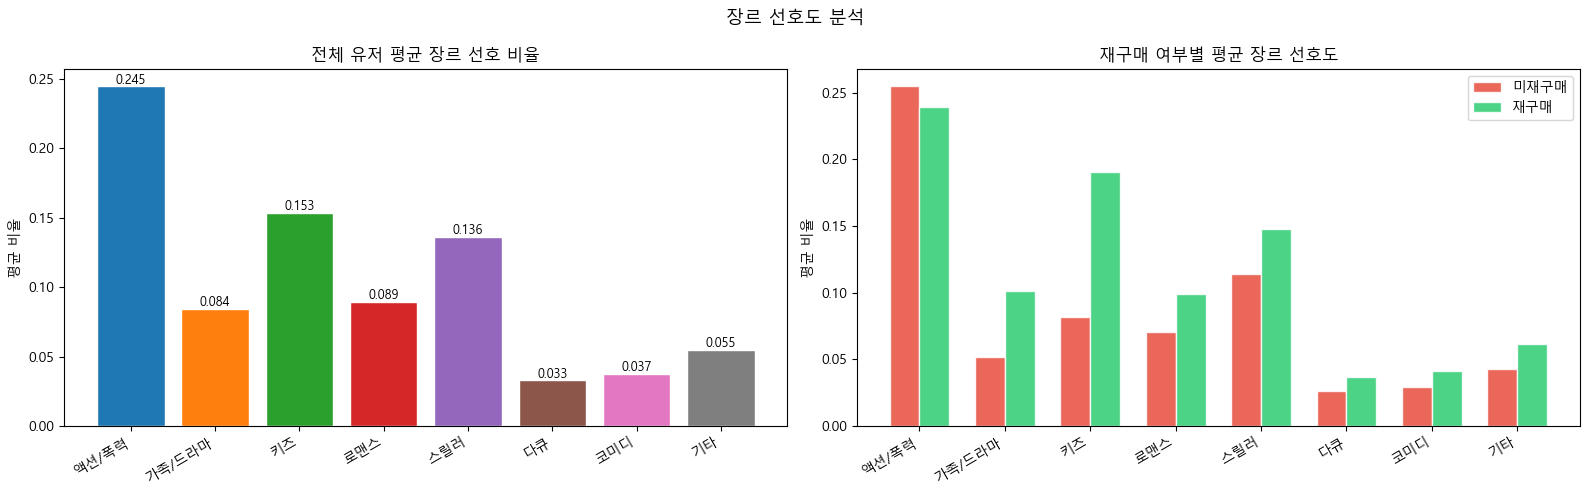

In [20]:
# 장르 선호도 분석
genre_cols = ['ratio_action_violent','ratio_family_drama','ratio_kids',
              'ratio_romance','ratio_thriller','ratio_documentary',
              'ratio_comedy','ratio_etc']
genre_labels = ['액션/폭력','가족/드라마','키즈','로맨스','스릴러','다큐','코미디','기타']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 전체 장르 평균 비율 (레이더 대신 bar)
genre_means = um[genre_cols].mean()
genre_means.index = genre_labels
colors_g = sns.color_palette('tab10', len(genre_cols))
bars = axes[0].bar(genre_means.index, genre_means.values, color=colors_g, edgecolor='white')
axes[0].set_title('전체 유저 평균 장르 선호 비율', fontsize=12)
axes[0].set_ylabel('평균 비율')
axes[0].set_xticklabels(genre_labels, rotation=30, ha='right')
for bar, v in zip(bars, genre_means.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{v:.3f}', ha='center', fontsize=9)

# 재구매 vs 미재구매 장르 비율 비교
genre_by_rp = um.groupby('repurchase_label')[genre_cols].mean()
genre_by_rp.columns = genre_labels
x = np.arange(len(genre_labels))
width = 0.35
for i, (label, row) in enumerate(genre_by_rp.iterrows()):
    axes[1].bar(x + i*width, row.values, width,
                label=f'{"재구매" if label==1 else "미재구매"}',
                color=['#E74C3C','#2ECC71'][i], edgecolor='white', alpha=0.85)
axes[1].set_title('재구매 여부별 평균 장르 선호도', fontsize=12)
axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(genre_labels, rotation=30, ha='right')
axes[1].set_ylabel('평균 비율')
axes[1].legend()

plt.suptitle('장르 선호도 분석', fontsize=13)
plt.tight_layout()
plt.show()

# Membership.csv EDA — repurchase(재구매) 예측 분석
> repurchase(O=재구매, NaN=미재구매)를 이진 타깃(1/0)으로 변환하여 각 변수와의 관계를 탐색합니다.

In [55]:
# ─── 데이터 로드 & 기본 전처리 ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib import rc

rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

mem = pd.read_csv("Membership.csv")
mem["repurchase_label"] = mem["repurchase"].apply(lambda x: 1 if x == "O" else 0)
mem["rp_str"] = mem["repurchase_label"].map({1: "재구매", 0: "미재구매"})

print("Shape:", mem.shape)
print("\n=== 결측치 현황 ===")
print(mem.isnull().sum()[mem.isnull().sum() > 0])
print("\n=== 타깃 분포 ===")
print(mem["repurchase_label"].value_counts())
print(f"\n재구매율: {mem['repurchase_label'].mean():.1%}")


Shape: (18183, 17)

=== 결측치 현황 ===
concurrent_streams       70
promotion_yn           8980
is_churn_prevented    14926
repurchase             6252
is_user_verified        600
gender                  164
age                     164
dtype: int64

=== 타깃 분포 ===
repurchase_label
1    11931
0     6252
Name: count, dtype: int64

재구매율: 65.6%


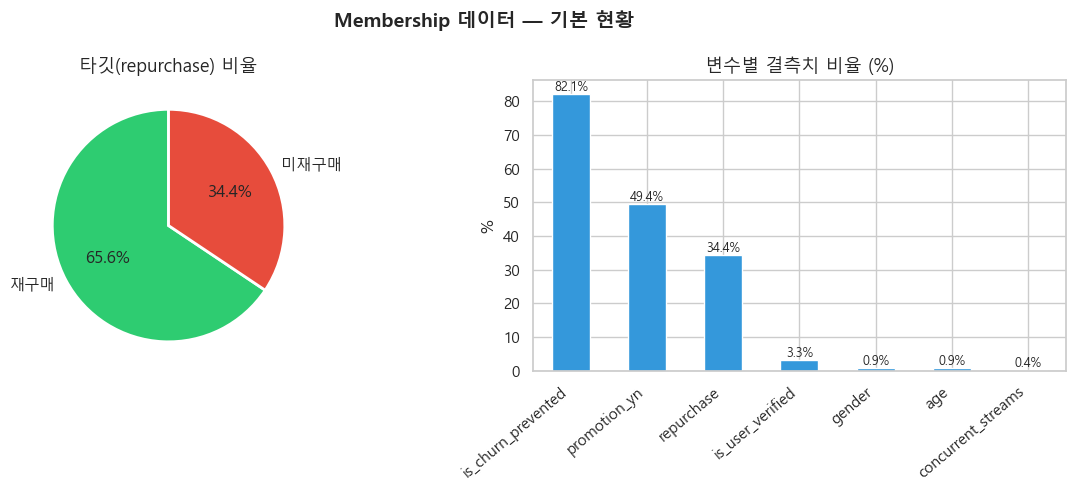

In [56]:
import matplotlib.pyplot as plt
import platform

# ─── 한글 폰트 설정 (이 부분을 추가해야 안 깨집니다) ───
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 윈도우 (맑은 고딕)
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic') # 맥 (애플 고딕)
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스/코랩 (나눔 바른고딕)

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# ─── 1. 타깃 분포 파이차트 & 결측치 현황 ───
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 데이터 프레임 변수명이 mem인지 확인하세요! (위 질문들에서는 membership/df 등으로 쓰였습니다)
counts = mem["repurchase_label"].value_counts()
axes[0].pie(counts, labels=["재구매", "미재구매"],
            colors=["#2ECC71", "#E74C3C"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("타깃(repurchase) 비율", fontsize=13)

null_pct = mem.isnull().mean().sort_values(ascending=False) * 100
null_pct = null_pct[null_pct > 0]

if not null_pct.empty:
    null_pct.plot(kind="bar", ax=axes[1], color="#3498DB", edgecolor="white")
    axes[1].set_title("변수별 결측치 비율 (%)", fontsize=13)
    axes[1].set_ylabel("%")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha="right")
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.1f}%",
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha="center", va="bottom", fontsize=9)
else:
    axes[1].text(0.5, 0.5, '결측치 없음', ha='center', va='center', fontsize=12)
    axes[1].set_title("변수별 결측치 비율 (%)", fontsize=13)

plt.suptitle("Membership 데이터 — 기본 현황", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [58]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 1. 시스템에 설치된 '맑은 고딕' 폰트 경로 직접 지정 (가장 확실한 방법)
if platform.system() == 'Windows':
    font_path = "C:/Windows/Fonts/malgun.ttf" # 윈도우 맑은 고딕 경로
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
elif platform.system() == 'Darwin': # 맥(Mac)
    plt.rc('font', family='AppleGothic')
else: # 리눅스
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 3. 그래프 선명하게 설정 (선택 사항)
%config InlineBackend.figure_format = 'retina'

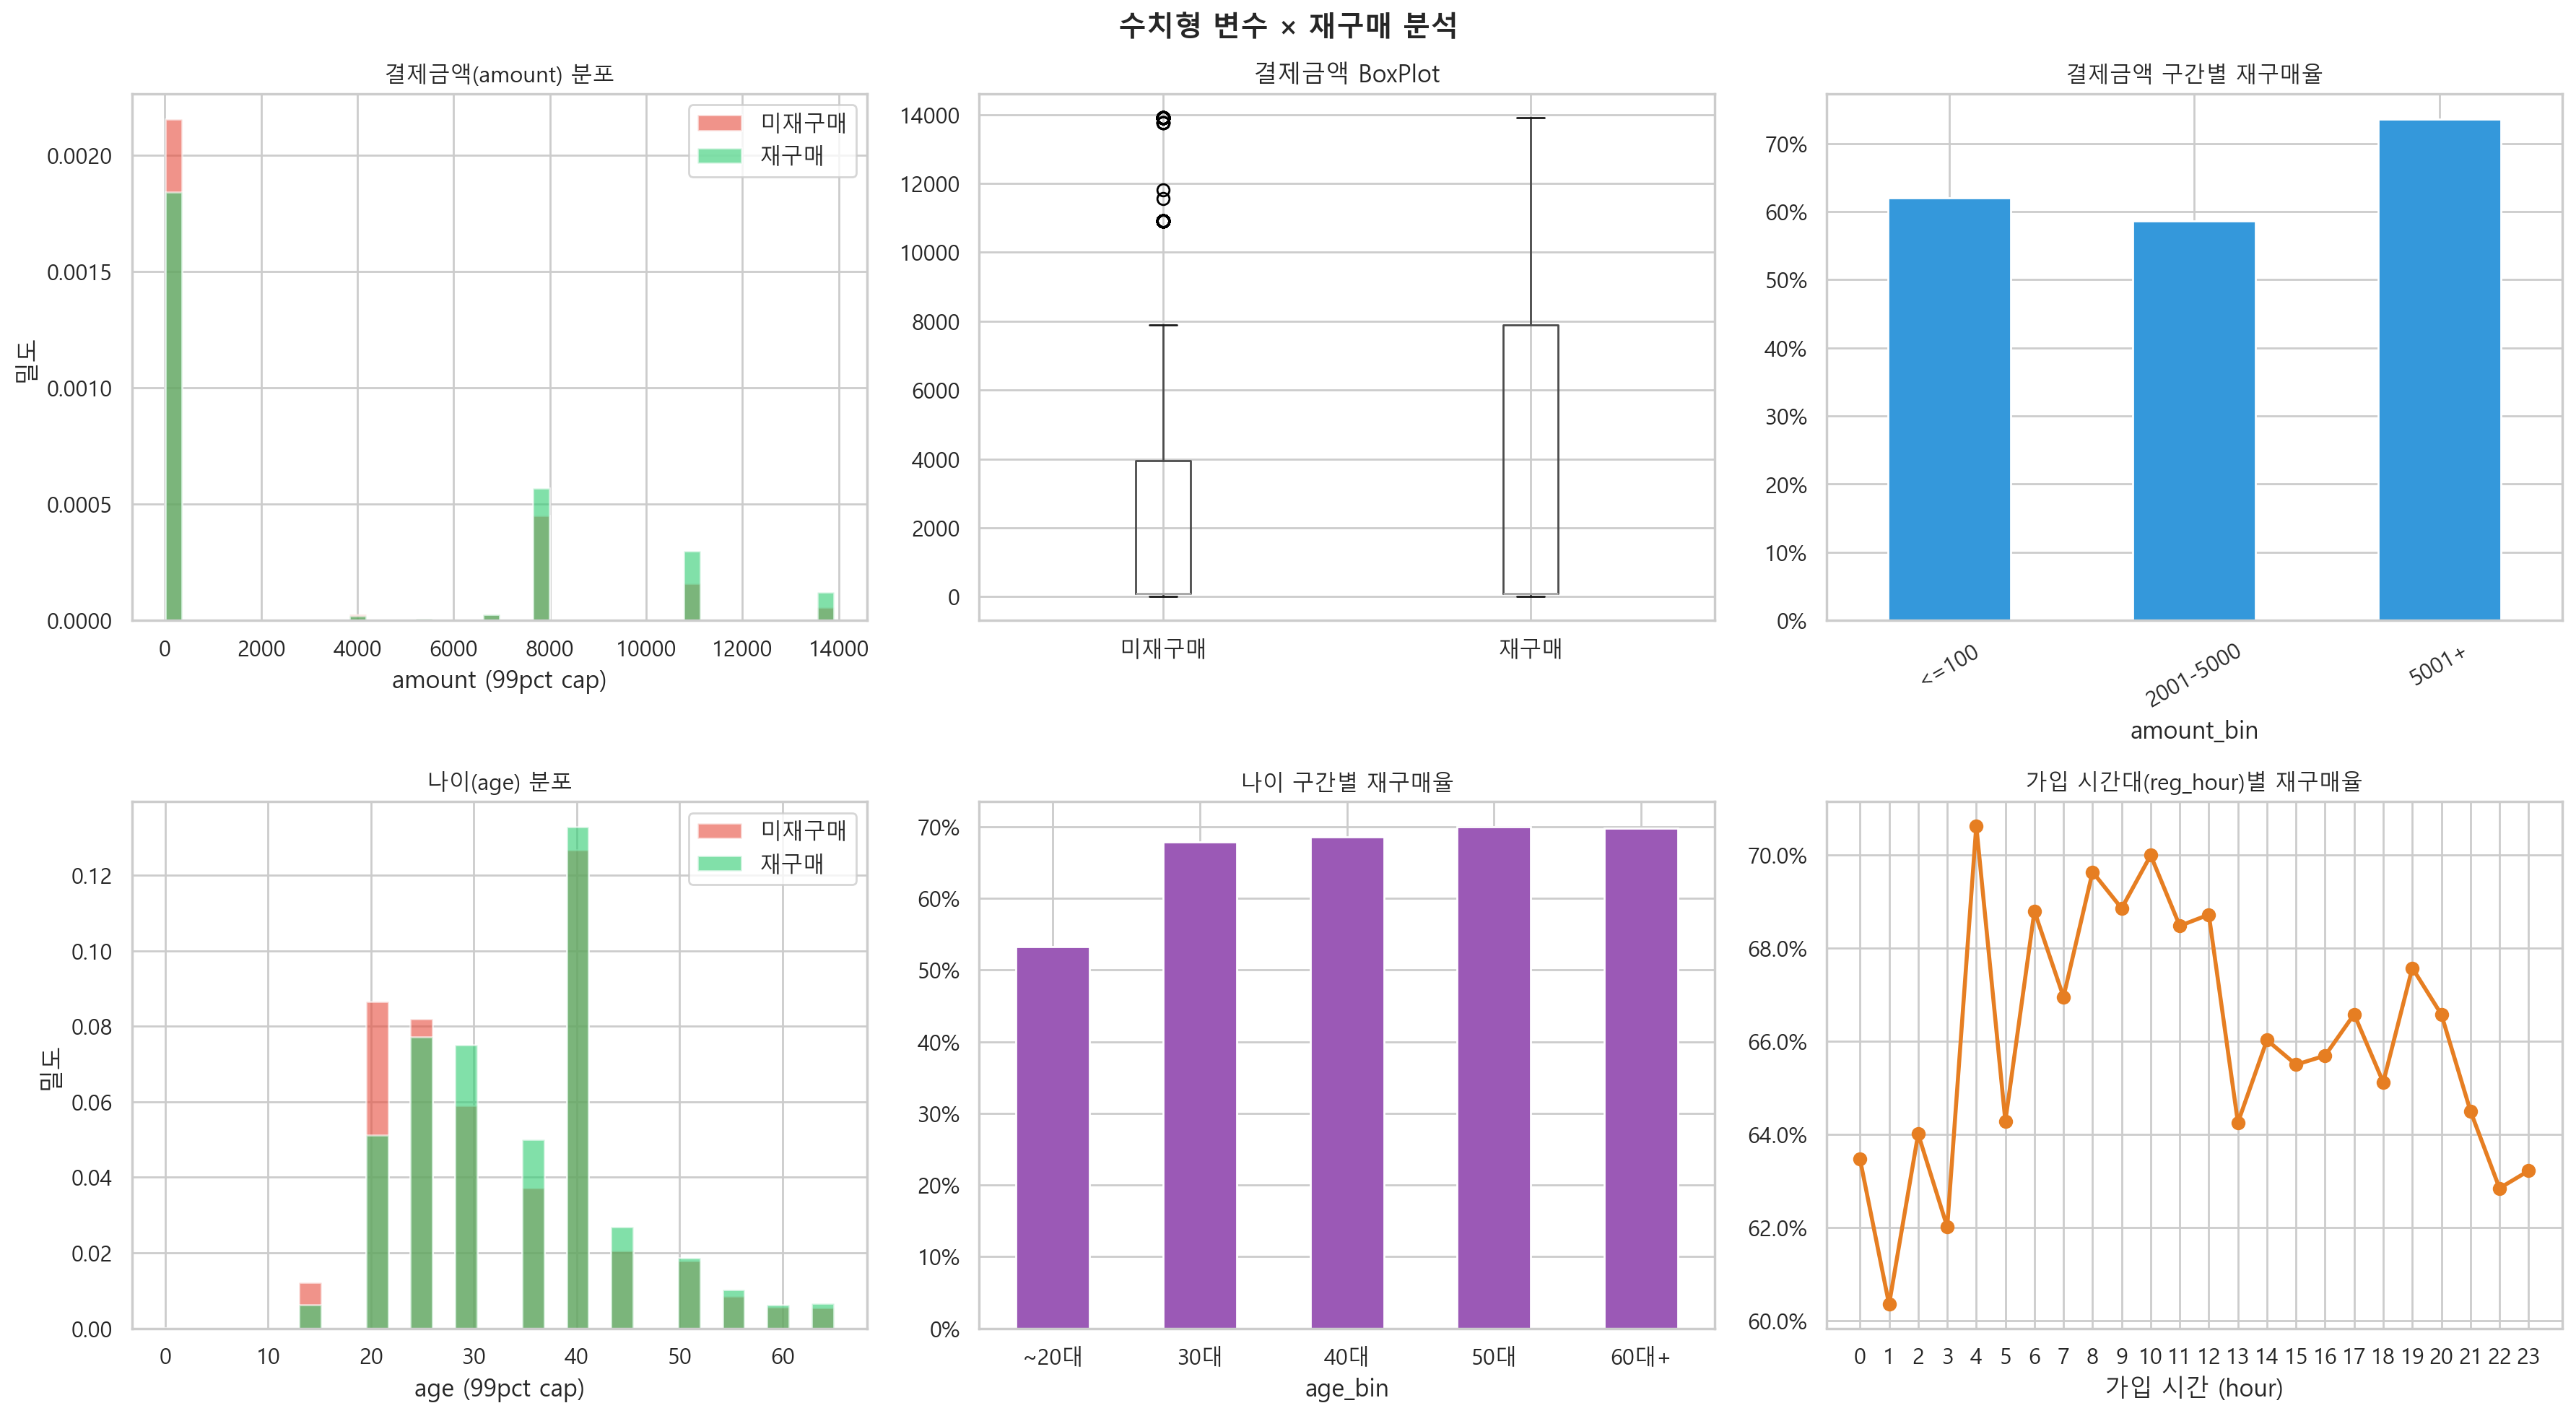

In [59]:
# ─── 3. 수치형 변수 — amount, age, reg_hour × 재구매 ───
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

amt_cap = mem["amount"].quantile(0.99)
mem["amount_clipped"] = mem["amount"].clip(upper=amt_cap)

for label, color in zip([0, 1], ["#E74C3C", "#2ECC71"]):
    axes[0,0].hist(mem[mem["repurchase_label"]==label]["amount_clipped"],
                   bins=40, alpha=0.6, color=color,
                   label=["미재구매","재구매"][label], density=True)
axes[0,0].set_title("결제금액(amount) 분포", fontsize=11)
axes[0,0].set_xlabel("amount (99pct cap)")
axes[0,0].set_ylabel("밀도")
axes[0,0].legend()

mem.boxplot(column="amount_clipped", by="rp_str", ax=axes[0,1])
axes[0,1].set_xlabel("")
plt.sca(axes[0,1]); plt.title("결제금액 BoxPlot")

mem["amount_bin"] = pd.cut(mem["amount"],
                           bins=[0,100,500,2000,5000,16500],
                           labels=["<=100","101-500","501-2000","2001-5000","5001+"])
amt_rp = mem.groupby("amount_bin", observed=True)["repurchase_label"].mean()
amt_rp.plot(kind="bar", ax=axes[0,2], color="#3498DB", edgecolor="white")
axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0,2].set_title("결제금액 구간별 재구매율", fontsize=11)
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=30)

age_cap = mem["age"].quantile(0.99)
mem["age_clipped"] = mem["age"].clip(upper=age_cap)
for label, color in zip([0, 1], ["#E74C3C", "#2ECC71"]):
    axes[1,0].hist(mem[mem["repurchase_label"]==label]["age_clipped"].dropna(),
                   bins=30, alpha=0.6, color=color,
                   label=["미재구매","재구매"][label], density=True)
axes[1,0].set_title("나이(age) 분포", fontsize=11)
axes[1,0].set_xlabel("age (99pct cap)")
axes[1,0].set_ylabel("밀도")
axes[1,0].legend()

mem["age_bin"] = pd.cut(mem["age_clipped"],
                        bins=[0,20,30,40,50,100],
                        labels=["~20대","30대","40대","50대","60대+"])
age_rp = mem.groupby("age_bin", observed=True)["repurchase_label"].mean()
age_rp.plot(kind="bar", ax=axes[1,1], color="#9B59B6", edgecolor="white")
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1,1].set_title("나이 구간별 재구매율", fontsize=11)
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

hour_rp = mem.groupby("reg_hour")["repurchase_label"].mean()
axes[1,2].plot(hour_rp.index, hour_rp.values, marker="o", color="#E67E22", linewidth=2)
axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1,2].set_title("가입 시간대(reg_hour)별 재구매율", fontsize=11)
axes[1,2].set_xlabel("가입 시간 (hour)")
axes[1,2].set_xticks(range(0, 24))

plt.suptitle("수치형 변수 × 재구매 분석", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


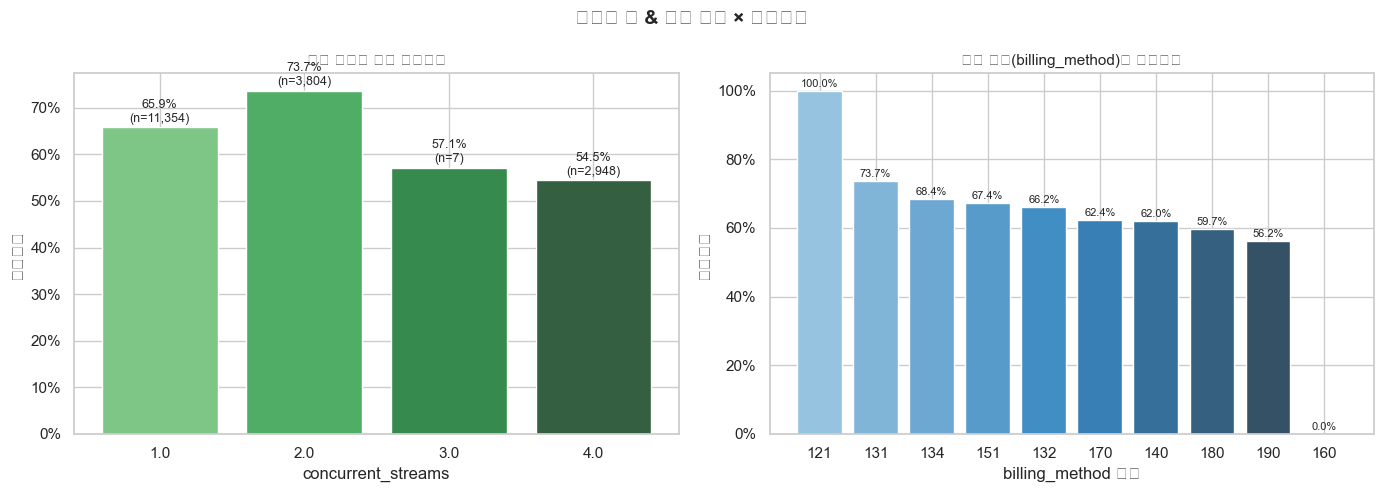

In [53]:
# ─── 4. concurrent_streams & billing_method × 재구매율 ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cs_rp = (mem.dropna(subset=["concurrent_streams"])
             .groupby("concurrent_streams")["repurchase_label"]
             .agg(["mean","count"]).reset_index())
bars = axes[0].bar(cs_rp["concurrent_streams"].astype(str),
                   cs_rp["mean"],
                   color=sns.color_palette("Greens_d", len(cs_rp)), edgecolor="white")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("동시 스트림 수별 재구매율", fontsize=11)
axes[0].set_xlabel("concurrent_streams")
axes[0].set_ylabel("재구매율")
for bar, row in zip(bars, cs_rp.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{row.mean:.1%}\n(n={row.count:,})",
                 ha="center", va="bottom", fontsize=9)

bm_rp = (mem.groupby("billing_method")["repurchase_label"]
            .agg(["mean","count"]).reset_index()
            .sort_values("mean", ascending=False))
bars2 = axes[1].bar(bm_rp["billing_method"].astype(str),
                    bm_rp["mean"],
                    color=sns.color_palette("Blues_d", len(bm_rp)), edgecolor="white")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("결제 방식(billing_method)별 재구매율", fontsize=11)
axes[1].set_xlabel("billing_method 코드")
axes[1].set_ylabel("재구매율")
for bar, row in zip(bars2, bm_rp.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{row.mean:.1%}", ha="center", va="bottom", fontsize=8)

plt.suptitle("스트림 수 & 결제 방식 × 재구매율", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


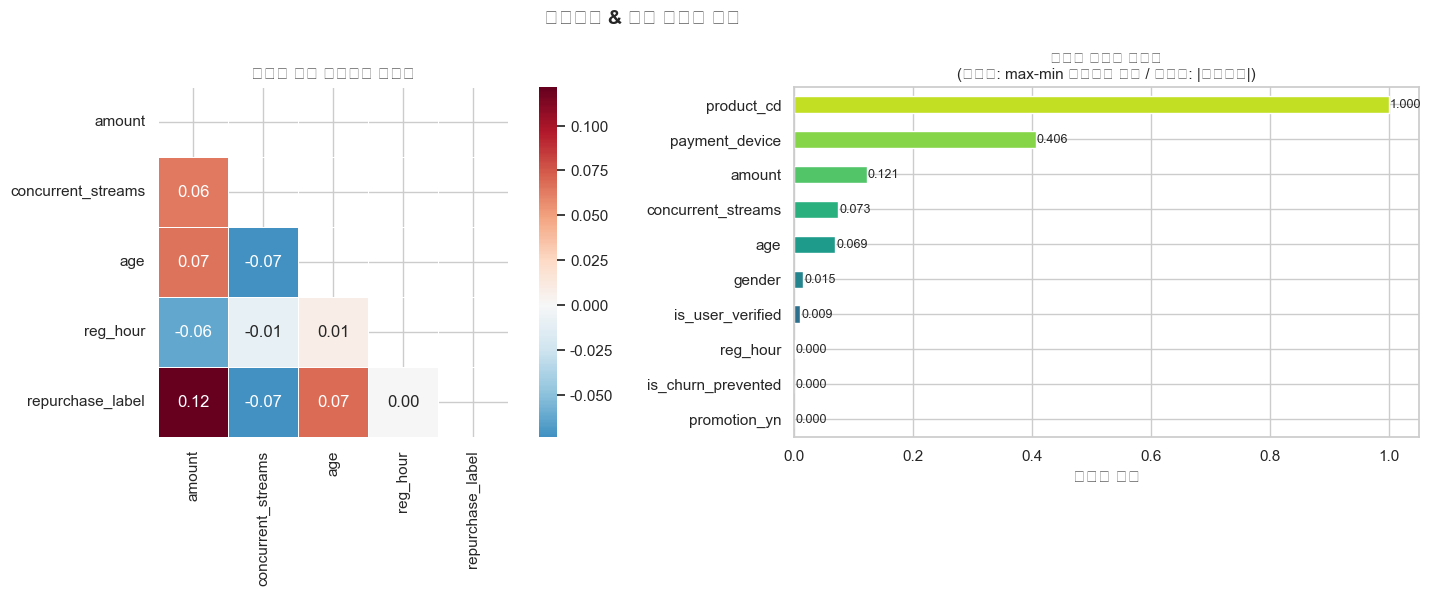


=== 재구매율 영향력 순위 ===
product_cd            1.000000
payment_device        0.406058
amount                0.121463
concurrent_streams    0.073144
age                   0.068512
gender                0.014556
is_user_verified      0.009230
reg_hour              0.000329
promotion_yn          0.000000
is_churn_prevented    0.000000


In [54]:
# ─── 5. 상관관계 히트맵 & 변수 영향력 요약 ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

num_cols = ["amount", "concurrent_streams", "age", "reg_hour", "repurchase_label"]
corr = mem[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, mask=mask,
            linewidths=0.5, square=True)
axes[0].set_title("수치형 변수 상관관계 히트맵", fontsize=12)

summary = {}
for col in ["product_cd","payment_device","gender",
             "promotion_yn","is_churn_prevented","is_user_verified"]:
    g = mem.groupby(col)["repurchase_label"].mean()
    summary[col] = g.max() - g.min()
for col in ["amount","age","reg_hour","concurrent_streams"]:
    summary[col] = abs(mem[[col,"repurchase_label"]].corr().iloc[0,1])

summary_s = pd.Series(summary).sort_values(ascending=True)
summary_s.plot(kind="barh", ax=axes[1],
               color=sns.color_palette("viridis", len(summary_s)), edgecolor="white")
axes[1].set_title(
    "변수별 재구매 영향력\n(범주형: max-min 재구매율 차이 / 수치형: |상관계수|)", fontsize=11)
axes[1].set_xlabel("영향력 지표")
for p in axes[1].patches:
    axes[1].text(p.get_width() + 0.002, p.get_y() + p.get_height()/2,
                 f"{p.get_width():.3f}", va="center", fontsize=9)

plt.suptitle("상관관계 & 변수 중요도 요약", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== 재구매율 영향력 순위 ===")
print(summary_s.sort_values(ascending=False).to_string())
